In [2]:
"""
Created on: 18-08-2026

@author B.A. Sturre

PyTorch tutorial 
https://www.youtube.com/watch?v=c36lUUr864M 
"""

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets 
import torch
import torch.nn as nn

## Linear Regression example

In [9]:
# prepare data: generate regression dataset 
x_np, y_np = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)  # double datatype

x = torch.from_numpy(x_np.astype(np.float32))
y = torch.from_numpy(y_np.astype(np.float32))  
y = y.view(y.shape[0], 1)  # we want to make it a column vector

n_samples, n_features = x.shape

# define model 
input_size = n_features
output_size = 1
model = nn.Linear(input_size, output_size)

# loss and optimizer
learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# training loop 
num_epochs = 100 
for epoch in range(num_epochs): 
    # forward pass 
    y_pred = model(x)

    # loss 
    loss = criterion(y_pred, y)

    # backward pass 
    loss.backward()

    # update
    optimizer.step()

    optimizer.zero_grad()

    if epoch % 10 == 9: 
        print(f'epoch {epoch+1}: loss = {loss.item():.4f}')

epoch 10: loss = 4336.3569
epoch 20: loss = 3236.5457
epoch 30: loss = 2440.7102
epoch 40: loss = 1864.2245
epoch 50: loss = 1446.2203
epoch 60: loss = 1142.8531
epoch 70: loss = 922.4998
epoch 80: loss = 762.3207
epoch 90: loss = 645.8007
epoch 100: loss = 560.9846


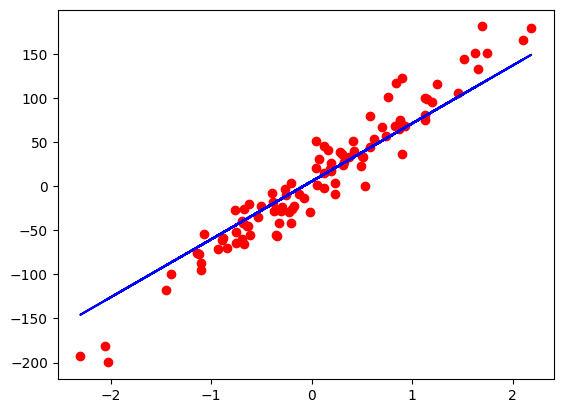

In [16]:
predicted = model(x).detach()  # such that we don't modify x itself
predicted = predicted.numpy()

# plotting 
plt.plot(x_np, y_np, 'ro')
plt.plot(x_np, predicted, 'b')
plt.show()